# Yee et al. — suggested structure candidates

Browses the output of `python -m src.inference` on the Yee dataset (477 spectra,
100 generated candidates each) and surfaces the **top 10** candidates per spectrum.

There are no ground-truth structures for this dataset, so nothing here is an
accuracy measurement — it is a *shortlist* for manual inspection.

**How the 100 are cut to 10.** Two independent signals are computed per candidate
and either can drive the ranking (`RANK_BY` below):

| signal | what it means |
|---|---|
| `count` | how many of the 100 samples produced this exact structure. The repo's top-k convention (`K_ACC_Collection`, `rank_candidates` in `feature_difficulty_analysis_ddp.ipynb`) ranks by this. On this run the decoder is very diverse — ~79 unique structures per 100 samples, and for ~40% of spectra even the *most* frequent candidate appears only once — so on its own it cannot order a top 10. |
| `cos_fp` | cosine similarity between the encoder's **predicted fingerprint** (the raw 2048-d vector in `predicted_fingerprints.pt`, read straight off the spectrum) and the candidate's Morgan fingerprint. Threshold-free, and it separates candidates even when every count is 1. This is the default. |

`tanimoto_fp` is also reported: the same comparison after binarising the predicted
fingerprint by taking its top-N scoring bits (N matched per spectrum to the median
on-bit count of that spectrum's candidates). It is thresholded and therefore
coarser than `cos_fp`, but it is on the familiar 0–1 Tanimoto scale.

**Read `cos_fp` as an ordering, not as a probability.** The predicted vector is raw
encoder output, not a calibrated 0–1 fingerprint, so the absolute numbers land in
0.03–0.17 and mean nothing on their own. Within one spectrum the ordering is the
product; across spectra the numbers are only loosely comparable.

**One more filter is free here:** the target molecular formula is known for every
Yee spectrum. The decoder is constrained to the right heavy atoms but *not* to the
right hydrogen count, so a candidate can come back with the wrong degree of
unsaturation — only ~2.4 of the 10 shortlisted structures match the formula exactly.
Those that don't are definitively wrong, so `PREFER_FORMULA_MATCH` sorts them last
by default. It is a preference, not a filter: 37% of spectra have no exact match
among their 100 candidates at all, and for those the shortlist would otherwise be
empty.

## 1. Configuration and imports

In [4]:
import glob
import os
import pickle as pkl
import sys
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, rdMolDescriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdMolDescriptors import CalcMolFormula
from IPython.display import display

RDLogger.DisableLog('rdApp.*')
IPythonConsole.molSize = (400, 300)
sys.path.append('../src')

# ---- knobs -----------------------------------------------------------------
TOP_K   = 10        # candidates kept per spectrum
RANK_BY = 'cos_fp'  # 'cos_fp' | 'count_then_fp' | 'count'

# Sort exact-formula candidates ahead of the rest, then apply RANK_BY within each
# group. Set False to rank on the score alone.
PREFER_FORMULA_MATCH = True
# cos_fp is rounded to this many decimals for the *sort key only*, so that
# candidates the fingerprint cannot tell apart fall back on generation count
# instead of being ordered by 4th-decimal noise. Reported values are unrounded.
TIE_ROUND = 3

# Must match configs/dataset/yee.yaml (morgan_r / morgan_nbits) — the encoder was
# trained to predict this exact fingerprint, so scoring against any other radius
# or width compares two different things.
MORGAN_R, MORGAN_NBITS = 2, 2048

# Run directory: outputs/<date>/<time>-inference produced by src/inference.py.
RUN_GLOB = 'data/outputs/*/*-inference'
CACHE    = 'data/candidates_cache.pkl'   # rebuilt table, ~1 min to compute

# Optional: the input spectra, for the spectrum panel in the viewer. Not copied
# down with the outputs by default — the viewer degrades gracefully without it.
SPEC_PKL = '../data/yee/df_neims_yee_3_9_22.pkl'

# Categorical slots 1-3 of the validated default palette (blue / orange / aqua).
C1, C2, C3 = '#2a78d6', '#eb6834', '#1baf7a'
GRID_KW = dict(color='0.85', linewidth=0.6)

_runs = sorted(glob.glob(RUN_GLOB))
if not _runs:
    raise FileNotFoundError(f'No inference run found under {RUN_GLOB}')
if len(_runs) > 1:
    print('Multiple runs found, using the last one. Set RUN_DIR by hand to pick another:')
    for r in _runs:
        print('   ', r)
RUN_DIR = _runs[-1]
print('RUN_DIR =', RUN_DIR)

RUN_DIR = data/outputs/2026-08-05/16-34-13-inference


## 2. Load the run artifacts

`src/inference.py` writes five files per run. We need three of them: the generated
molecules, the spectrum names (row order of everything else), and the predicted
fingerprints. `fp.txt` is skipped deliberately — it binarises at `>= 0.5`, but the
predicted vectors top out around 0.54, so that file is essentially all zeros. The
raw `.pt` tensor is what carries the signal.

In [5]:
with open(os.path.join(RUN_DIR, 'generated_mols.pkl'), 'rb') as f:
    generated_mols = pkl.load(f)                     # [n_spectra][n_samples] of Mol|None

names = np.loadtxt(os.path.join(RUN_DIR, 'batch_names.txt'), dtype=np.str_).tolist()
pred_fps = torch.load(os.path.join(RUN_DIR, 'predicted_fingerprints.pt')).float().numpy()
summary = pd.read_csv(os.path.join(RUN_DIR, 'results_summary.csv'))

assert len(generated_mols) == len(names) == len(pred_fps) == len(summary), (
    f'row mismatch: mols={len(generated_mols)} names={len(names)} '
    f'fps={len(pred_fps)} summary={len(summary)}')

# formula per spectrum, from the summary CSV (inference.py takes it off the graph's
# InChI stub, which is the formula the model was constrained to).
formula_of = dict(zip(summary['uid'], summary['formula']))

N_SPECTRA  = len(generated_mols)
N_SAMPLES  = len(generated_mols[0])
print(f'{N_SPECTRA} spectra x {N_SAMPLES} generated candidates')
print(f'predicted fingerprints: {pred_fps.shape}, range [{pred_fps.min():.3f}, {pred_fps.max():.3f}]')
summary.head()

477 spectra x 100 generated candidates
predicted fingerprints: (477, 2048), range [-0.408, 0.543]


,uid,formula,num_valid,num_samples,validity_rate,unique_smiles,top_smiles
0,LDY-1619,C17H44O4Si4,100,100,1.0,99,CCCC[Si](C)(O)CC(CCO[Si](C)(C)O[Si](C)(C)C)O[S...
1,LDY-1988,C17H44O4Si4,100,100,1.0,96,C=C[Si]1(C(C)(C)C)O[Si](C)(C)O[Si](C)(C)O[Si](...
2,LDY-3831,C17H30O4Si,100,100,1.0,99,CCCCCCCCC(C)O[Si](C)(O)OC(CC)CC(C)=O
3,LDY-5380,C17H30O4Si,100,100,1.0,100,CCCCCC(=O)CCC[Si](C)(OOCC)OC(C)CCC
4,LDY-6914,C15H30O4Si2,100,100,1.0,96,CC1(C(O[Si](C)(C)C)C2(O[Si](C)(C)C)CCCC2)OC1=O


## 3. Molecule helpers

`is_valid` / `mol2smiles` are lifted from `src/utils.py` rather than imported: the
import chain there pulls in `omegaconf` and the model code, none of which this
notebook needs. Note that `Chem.SanitizeMol` mutates in place, so a mol that has
passed `is_valid` has its ring info initialised and is safe to fingerprint —
straight off the pickle it is not, and `GetMorganFingerprintAsBitVect` raises
*"RingInfo not initialized"*.

In [6]:
def mol2smiles(mol):
    """src/utils.py: sanitize in place, return canonical SMILES or None."""
    try:
        Chem.SanitizeMol(mol)
    except ValueError:
        return None
    return Chem.MolToSmiles(mol)


def is_valid(mol):
    """src/utils.py: sanitizable and a single connected fragment."""
    if mol is None:
        return False
    if mol2smiles(mol) is None:
        return False
    try:
        frags = Chem.rdmolops.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    except Exception:
        return False
    return len(frags) == 1


def morgan_bits(mol, r=MORGAN_R, nbits=MORGAN_NBITS):
    """Morgan fingerprint as a uint8 numpy array. Assumes `mol` is sanitized."""
    bv = AllChem.GetMorganFingerprintAsBitVect(mol, r, nBits=nbits)
    arr = np.zeros((nbits,), dtype=np.uint8)
    DataStructs.ConvertToNumpyArray(bv, arr)
    return arr


def parse_formula(formula):
    """'C17H44O4Si4' -> {'C': 17, 'H': 44, 'O': 4, 'Si': 4}."""
    import re
    return {el: int(n) if n else 1
            for el, n in re.findall(r'([A-Z][a-z]*)(\d*)', formula) if el}


def formula_matches(mol, target_formula):
    """Does the candidate have exactly the target molecular formula (H included)?"""
    try:
        return parse_formula(CalcMolFormula(mol)) == parse_formula(target_formula)
    except Exception:
        return False


# Descriptor panel, trimmed from feature_difficulty_analysis_ddp.ipynb to the
# columns that mean something for silylated atmospheric compounds.
def compute_descriptors(mol):
    n_c = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 6)
    n_o = sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 8)
    n_r = rdMolDescriptors.CalcNumRings(mol)
    return {
        'MW':         Descriptors.ExactMolWt(mol),
        'LogP':       Descriptors.MolLogP(mol),
        'TPSA':       rdMolDescriptors.CalcTPSA(mol),
        'RotBonds':   rdMolDescriptors.CalcNumRotatableBonds(mol),
        'AllRings':   n_r,
        'ArRings':    rdMolDescriptors.CalcNumAromaticRings(mol),
        'HeavyAtoms': mol.GetNumHeavyAtoms(),
        'nSi':        sum(1 for a in mol.GetAtoms() if a.GetAtomicNum() == 14),
        'O_C_ratio':  n_o / max(n_c, 1),
    }

## 4. Score and rank the candidates

For each spectrum: keep the valid candidates, collapse duplicates by InChI (this is
`rank_candidates` from `feature_difficulty_analysis_ddp.ipynb`), then score every
unique structure against the encoder's predicted fingerprint.

`cos_fp` uses the **raw** predicted vector, so no threshold is chosen anywhere.
`tanimoto_fp` needs a binary vector, so the predicted fingerprint is binarised by
keeping its N highest-scoring bits, with N set per spectrum to the median on-bit
count of that spectrum's own candidates — that way the two fingerprints being
compared carry comparable bit budgets, which a fixed global threshold does not
guarantee (bit counts at threshold 0.2 range from a handful to ~100 across spectra).

Takes ~1 minute for 477 x 100 molecules (InChI generation dominates); the result is
cached to `CACHE`, so delete that file to force a rebuild.

*A displayed `cos_fp` can look marginally out of order — rank 3 at 0.1160 above
rank 2 at 0.1159.* That is `TIE_ROUND`: candidates whose scores agree to three
decimals are one group, ordered by generation count, and the reported `cos_fp` is
the unrounded value.

In [7]:
def score_spectrum(mols, pred_fp, uid, formula):
    """One spectrum's 100 raw samples -> a DataFrame of unique scored candidates."""
    valid = [m for m in mols if is_valid(m)]           # sanitizes in place
    if not valid:
        return pd.DataFrame()

    by_inchi = {}
    for m in valid:
        key = Chem.MolToInchi(m)
        if not key:
            continue
        if key in by_inchi:
            by_inchi[key]['count'] += 1
        else:
            by_inchi[key] = {'mol': m, 'count': 1}
    if not by_inchi:
        return pd.DataFrame()

    fps = {k: morgan_bits(v['mol']) for k, v in by_inchi.items()}

    # Binarise the predicted fp to the same bit budget the candidates use.
    n_on = int(np.median([fp.sum() for fp in fps.values()]))
    keep = np.argsort(pred_fp)[::-1][:max(n_on, 1)]
    pred_bin = np.zeros_like(pred_fp, dtype=np.uint8)
    pred_bin[keep] = 1

    pred_norm = np.linalg.norm(pred_fp)
    rows = []
    for key, rec in by_inchi.items():
        fp = fps[key]
        on = fp.astype(bool)
        # cosine(raw predicted vector, binary candidate fp)
        cos = pred_fp[on].sum() / (pred_norm * np.sqrt(on.sum())) if on.sum() else 0.0
        inter = int(np.bitwise_and(fp, pred_bin).sum())
        union = int(np.bitwise_or(fp, pred_bin).sum())
        rows.append({
            'uid':          uid,
            'formula':      formula,
            'smiles':       Chem.MolToSmiles(rec['mol']),
            'inchi':        key,
            'count':        rec['count'],
            'freq':         rec['count'] / len(mols),
            'cos_fp':       float(cos),
            'tanimoto_fp':  inter / union if union else 0.0,
            'formula_match': formula_matches(rec['mol'], formula),
            **compute_descriptors(rec['mol']),
        })
    return pd.DataFrame(rows)


def build_table():
    parts = []
    for i, (uid, mols) in enumerate(zip(names, generated_mols), 1):
        df = score_spectrum(mols, pred_fps[i - 1], uid, formula_of.get(uid, 'unknown'))
        if not df.empty:
            df['spectrum_idx'] = i - 1
            parts.append(df)
        if i % 100 == 0:
            print(f'  {i}/{N_SPECTRA} spectra scored', flush=True)
    return pd.concat(parts, ignore_index=True)


if os.path.exists(CACHE):
    cand = pd.read_pickle(CACHE)
    print(f'Loaded cached candidate table from {CACHE}')
else:
    cand = build_table()
    cand.to_pickle(CACHE)
    print(f'Built and cached candidate table -> {CACHE}')

print(f'{len(cand):,} unique candidates across {cand["uid"].nunique()} spectra')
cand.head(3)

  100/477 spectra scored
  200/477 spectra scored
  300/477 spectra scored
  400/477 spectra scored
Built and cached candidate table -> data/candidates_cache.pkl
32,189 unique candidates across 477 spectra


,uid,formula,smiles,inchi,count,freq,cos_fp,tanimoto_fp,formula_match,MW,LogP,TPSA,RotBonds,AllRings,ArRings,HeavyAtoms,nSi,O_C_ratio,spectrum_idx
0,LDY-1619,C17H44O4Si4,CCCC[Si](C)(O)CC(CCO[Si](C)(C)O[Si](C)(C)C)O[S...,"InChI=1S/C17H44O4Si4/c1-11-12-15-25(10,18)16-1...",1,0.01,0.015870,0.015152,True,424.231666,5.5342,47.92,13,0,0,25,4,0.235294,0
1,LDY-1619,C17H44O4Si4,CC[Si](C)(O[Si](C)(C)C)O[Si]1(C(C)(C)C(C)C)O[S...,"InChI=1S/C17H42O4Si4/c1-14-23(12,18-22(9,10)11...",1,0.01,0.021515,0.015873,False,422.216016,6.2404,36.92,7,1,0,25,4,0.235294,0
2,LDY-1619,C17H44O4Si4,CO[Si](C)(C)O[Si](C)(C)Cc1cccc(O[Si](C)(C)O[Si...,"InChI=1S/C17H36O4Si4/c1-18-24(7,8)21-23(5,6)15...",1,0.01,0.045649,0.015385,False,416.169066,5.2703,36.92,9,1,1,25,4,0.235294,0


In [8]:
SORT_KEYS = {
    'cos_fp':        (['_cos_r', 'count'],  [False, False]),
    'count_then_fp': (['count', '_cos_r'],  [False, False]),
    'count':         (['count', '_cos_r'],  [False, False]),
}

def top_candidates(df, k=TOP_K, rank_by=RANK_BY, prefer_formula=PREFER_FORMULA_MATCH):
    """Per-spectrum top-k, with a 1-based `rank` column."""
    by, asc = SORT_KEYS[rank_by]
    work = df.assign(_cos_r=df['cos_fp'].round(TIE_ROUND))
    if prefer_formula:
        by, asc = ['formula_match'] + by, [False] + asc
    out = (work.sort_values(['uid'] + by, ascending=[True] + asc)
               .groupby('uid', sort=False)
               .head(k)
               .drop(columns='_cos_r')
               .copy())
    out['rank'] = out.groupby('uid').cumcount() + 1
    return out.reset_index(drop=True)


top = top_candidates(cand)
print(f'top-{TOP_K} by {RANK_BY}'
      f'{", formula matches first" if PREFER_FORMULA_MATCH else ""}: {len(top):,} rows, '
      f'{top.groupby("uid").size().min()}-{top.groupby("uid").size().max()} candidates per spectrum')
top[top['rank'] <= 3][['uid', 'rank', 'smiles', 'count', 'cos_fp', 'tanimoto_fp', 'formula_match']].head(9)

top-10 by cos_fp, formula matches first: 4,761 rows, 6-10 candidates per spectrum


,uid,rank,smiles,count,cos_fp,tanimoto_fp,formula_match
0,LDY-10808,1,C=CCCC(=O)CCCCC1CCCCC(=O)O[Si](C)(C)O1,1,0.101603,0.012346,True
1,LDY-10808,2,CCO[Si]1(OC2CCCC(=O)C2)CCCCCCC(=O)CC1,1,0.080410,0.027778,True
2,LDY-10808,3,CC(=O)C1O[Si]23OCCCCCCCCCCCC2CC1O3,1,0.072245,0.014493,True
10,LDY-10849,1,CCCCCCCCC(C)O[Si]1(O)CCCC(CCCC)O1,1,0.113817,0.061538,False
11,LDY-10849,2,CCCCCCCC(C)O[Si]1(C)OC(CCCC)C(C)(C)O1,1,0.107315,0.063492,False
12,LDY-10849,3,CCCCCCCCCCC(C)O[Si]1(C)CC(CCC)OO1,1,0.104570,0.047619,False
20,LDY-15193,1,CCCCCCCCCCCCC(=O)O[Si]1(C)CCC1,1,0.116903,0.037037,True
21,LDY-15193,2,CCCCCCCCCC(=O)CCC1CC[Si](C)(C)O1,1,0.115910,0.033333,True
22,LDY-15193,3,CCCCCC[Si]1(CCCC)OC2CCC(CC)(C2)O1,1,0.116007,0.067797,True


## 5. Run overview

Sanity checks on the run as a whole, before looking at any individual spectrum.

In [9]:
per_spec = pd.DataFrame({
    'uid':           summary['uid'],
    'validity_rate': summary['validity_rate'],
    'n_unique':      summary['uid'].map(cand.groupby('uid').size()).fillna(0),
    'top1_count':    summary['uid'].map(top[top['rank'] == 1].set_index('uid')['count']),
    'top1_cos':      summary['uid'].map(top[top['rank'] == 1].set_index('uid')['cos_fp']),
    'fm_in_top10':   summary['uid'].map(top.groupby('uid')['formula_match'].sum()).fillna(0),
})

print(f'validity                     : {per_spec["validity_rate"].mean():.3f} mean per spectrum')
print(f'unique structures / 100      : {per_spec["n_unique"].mean():.1f} mean '
      f'({per_spec["n_unique"].min():.0f}-{per_spec["n_unique"].max():.0f})')
print(f'top-1 sampled more than once : {(per_spec["top1_count"] > 1).mean():.1%} of spectra')
print(f'exact formula match in top-10: {(per_spec["fm_in_top10"] > 0).mean():.1%} of spectra '
      f'({per_spec["fm_in_top10"].mean():.1f} of 10 on average)')
per_spec.describe().T

validity                     : 1.000 mean per spectrum
unique structures / 100      : 67.5 mean (6-99)
top-1 sampled more than once : 4.8% of spectra
exact formula match in top-10: 86.6% of spectra (7.2 of 10 on average)


,count,mean,std,min,25%,50%,75%,max
validity_rate,477.0,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.00000
n_unique,477.0,67.482180,20.317909,6.000000,55.00000,72.000000,83.000000,99.00000
top1_count,477.0,1.085954,0.492541,1.000000,1.00000,1.000000,1.000000,8.00000
top1_cos,477.0,0.086968,0.026884,-0.005888,0.06931,0.088815,0.106422,0.15754
fm_in_top10,477.0,7.241090,3.932005,0.000000,4.00000,10.000000,10.000000,10.00000


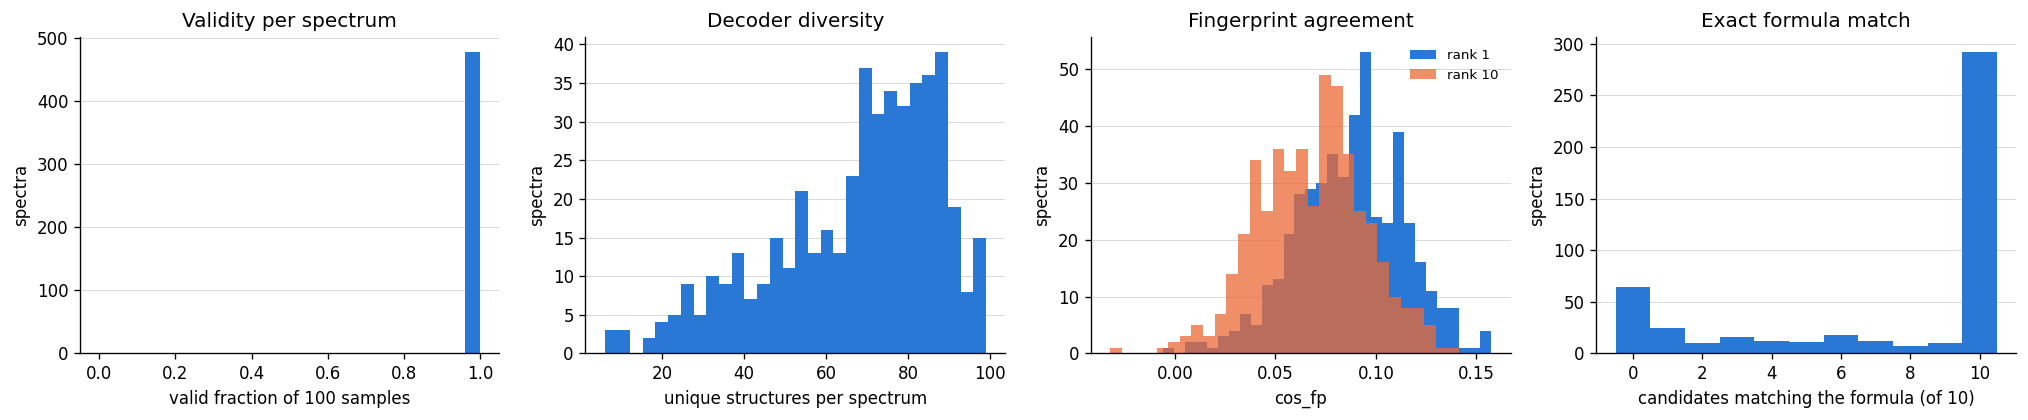

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6), dpi=120)

axes[0].hist(per_spec['validity_rate'], bins=np.linspace(0, 1, 26), color=C1)
axes[0].set_xlabel('valid fraction of 100 samples')
axes[0].set_title('Validity per spectrum')

axes[1].hist(per_spec['n_unique'], bins=30, color=C1)
axes[1].set_xlabel('unique structures per spectrum')
axes[1].set_title('Decoder diversity')

axes[2].hist(top[top['rank'] == 1]['cos_fp'], bins=30, color=C1, label='rank 1')
axes[2].hist(top[top['rank'] == TOP_K]['cos_fp'], bins=30, color=C2, alpha=0.75,
             label=f'rank {TOP_K}')
axes[2].set_xlabel('cos_fp')
axes[2].set_title('Fingerprint agreement')
axes[2].legend(frameon=False, fontsize=8)

axes[3].hist(per_spec['fm_in_top10'], bins=np.arange(-0.5, TOP_K + 1.5), color=C1)
axes[3].set_xlabel(f'candidates matching the formula (of {TOP_K})')
axes[3].set_title('Exact formula match')

for ax in axes:
    ax.set_ylabel('spectra')
    ax.grid(axis='y', **GRID_KW)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

The rank-1 vs rank-10 `cos_fp` histograms are the useful panel: where they overlap,
the shortlist is not really ordered and all ten deserve a look; where rank 1 sits
clearly to the right, the top candidate is the one the spectrum actually supports.
`spread` below makes that per-spectrum.

In [11]:
spread = (top.groupby('uid')['cos_fp'].agg(['max', 'min'])
             .assign(spread=lambda d: d['max'] - d['min'])
             .sort_values('spread', ascending=False))

print('Most decisive shortlists (rank 1 stands out most):')
display(spread.head(8).round(3))
print('Least decisive shortlists (all ten roughly equivalent):')
display(spread.tail(8).round(3))

Most decisive shortlists (rank 1 stands out most):


,max,min,spread
uid,,,
LDY-20120,0.144,0.013,0.131
LDY-17918,0.109,0.000,0.109
LDY-20578,0.118,0.015,0.103
LDY-20694,0.131,0.032,0.099
LDY-7484,0.126,0.028,0.098
LDY-20607,0.115,0.017,0.098
LDY-20640,0.085,-0.008,0.093
LDY-21686,0.090,-0.002,0.092


Least decisive shortlists (all ten roughly equivalent):


,max,min,spread
uid,,,
LDY-21139,0.113,0.104,0.009
LDY-20669,0.088,0.080,0.008
LDY-20673,0.105,0.097,0.008
LDY-20654,0.094,0.087,0.008
LDY-20682,0.109,0.102,0.007
LDY-21780,0.114,0.108,0.006
LDY-19026,0.100,0.095,0.004
LDY-21424,0.139,0.135,0.004


## 6. The viewer

`show(uid)` is the main entry point — pass a spectrum name (`'LDY-1619'`) or an
integer index. It draws the top-`TOP_K` structures as a grid, with a score bar
alongside, and prints the table of scores.

In [12]:
def _resolve(uid):
    """Accept a uid string or an integer position into `names`."""
    if isinstance(uid, (int, np.integer)):
        return names[uid]
    if uid not in formula_of:
        raise KeyError(f'{uid!r} is not one of the {len(names)} spectrum names')
    return uid


def candidate_grid(uid, k=TOP_K, table=None, mols_per_row=5, size=(300, 240)):
    """Grid image of a spectrum's top-k candidates, legends carrying the scores."""
    uid = _resolve(uid)
    t = (table if table is not None else top)
    rows = t[t['uid'] == uid].nsmallest(k, 'rank')
    if rows.empty:
        print(f'{uid}: no valid candidates')
        return None
    mols, legends = [], []
    for _, r in rows.iterrows():
        mols.append(Chem.MolFromSmiles(r['smiles']))
        legends.append(f"#{r['rank']}  cos={r['cos_fp']:.3f}  n={r['count']}"
                       + ('' if r['formula_match'] else '  [formula X]'))
    return Draw.MolsToGridImage(mols, molsPerRow=mols_per_row,
                                subImgSize=size, legends=legends)


def score_bars(uid, k=TOP_K, table=None):
    """Horizontal bars of the two fingerprint scores over a spectrum's shortlist."""
    uid = _resolve(uid)
    t = (table if table is not None else top)
    rows = t[t['uid'] == uid].nsmallest(k, 'rank')
    if rows.empty:
        return

    y = np.arange(len(rows))
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 0.34 * len(rows) + 1.4), dpi=120,
                             sharey=True)
    axes[0].barh(y, rows['cos_fp'], color=C1, height=0.62)
    axes[0].set_xlabel('cos_fp  (vs predicted fingerprint)')
    axes[1].barh(y, rows['tanimoto_fp'], color=C3, height=0.62)
    axes[1].set_xlabel('tanimoto_fp')

    for ax in axes:
        ax.invert_yaxis()
        ax.set_yticks(y)
        ax.set_yticklabels([f'#{r}' for r in rows['rank']], fontsize=8)
        ax.grid(axis='x', **GRID_KW)
        ax.set_axisbelow(True)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
    fig.suptitle(f'{uid} — {formula_of.get(uid, "?")}', fontsize=10)
    plt.tight_layout()
    plt.show()


def show(uid, k=TOP_K, table=None, bars=True, spectrum=True, cols=None):
    """Full panel for one spectrum: input spectrum, score bars, structure grid, table."""
    uid = _resolve(uid)
    t = (table if table is not None else top)
    rows = t[t['uid'] == uid].nsmallest(k, 'rank')
    n_gen = summary.loc[summary['uid'] == uid, 'num_valid'].iloc[0]
    n_uni = int(cand[cand['uid'] == uid].shape[0])

    print(f'=== {uid} ===  formula {formula_of.get(uid, "?")}  |  '
          f'{n_gen}/{N_SAMPLES} valid  |  {n_uni} unique structures  |  ranked by {RANK_BY}')

    if spectrum:
        plot_spectrum(uid)
    if bars:
        score_bars(uid, k, t)

    img = candidate_grid(uid, k, t)
    if img is not None:
        display(img)

    cols = cols or ['rank', 'smiles', 'count', 'cos_fp', 'tanimoto_fp',
                    'formula_match', 'MW', 'nSi', 'AllRings', 'O_C_ratio']
    print(rows[cols].round(3).to_string(index=False))

### Input-spectrum panel (optional)

Adapted from `make_fig` in `output_pickle_preds.ipynb`. It needs the collated
spectra pickle that inference read (`data/yee/df_neims_yee_3_9_22.pkl`, keyed by
`name`). That file is not part of the copied-down outputs, so if it is missing the
panel is skipped and everything else still works — copy it down from the cluster to
turn it on.

In [13]:
try:
    spec_df = pd.read_pickle(SPEC_PKL)
    HAVE_SPECTRA = 'name' in spec_df.columns and 'spec' in spec_df.columns
    print(f'Spectra loaded from {SPEC_PKL}: {len(spec_df)} rows')
except FileNotFoundError:
    spec_df, HAVE_SPECTRA = None, False
    print(f'No spectra at {SPEC_PKL} — the spectrum panel will be skipped.\n'
          'Copy the file down from the cluster to enable it.')


def plot_spectrum(uid, annotate=True, min_intensity=0.1):
    """EI-MS stick spectrum — the model input for this uid."""
    if not HAVE_SPECTRA:
        return
    uid = _resolve(uid)
    hit = spec_df[spec_df['name'] == uid]
    if hit.empty:
        print(f'  (no spectrum stored for {uid})')
        return

    spec = np.asarray(hit['spec'].values[0]).T
    mz, inten = spec[0, :], spec[1, :]
    inten = inten / inten.max()

    plt.figure(figsize=(8, 3.2), dpi=120)
    plt.vlines(mz, 0, inten, color=C1, linewidth=1.2)
    if annotate:
        for x, y in zip(mz, inten):
            if y >= min_intensity:
                plt.text(x, y + 0.02, f'{int(round(x))}', ha='center', va='bottom',
                         fontsize=7)
    plt.xlabel('m/z')
    plt.ylabel('Relative intensity')
    plt.ylim([0, 1.08])
    plt.title(f'EI-MS spectrum (model input) — {uid}', fontsize=11)
    plt.grid(axis='y', **GRID_KW)
    plt.gca().set_axisbelow(True)
    for s in ('top', 'right'):
        plt.gca().spines[s].set_visible(False)
    plt.tight_layout()
    plt.show()

Spectra loaded from ../data/yee/df_neims_yee_3_9_22.pkl: 477 rows


### Look at one spectrum

=== LDY-1619 ===  formula C17H44O4Si4  |  100/100 valid  |  71 unique structures  |  ranked by cos_fp


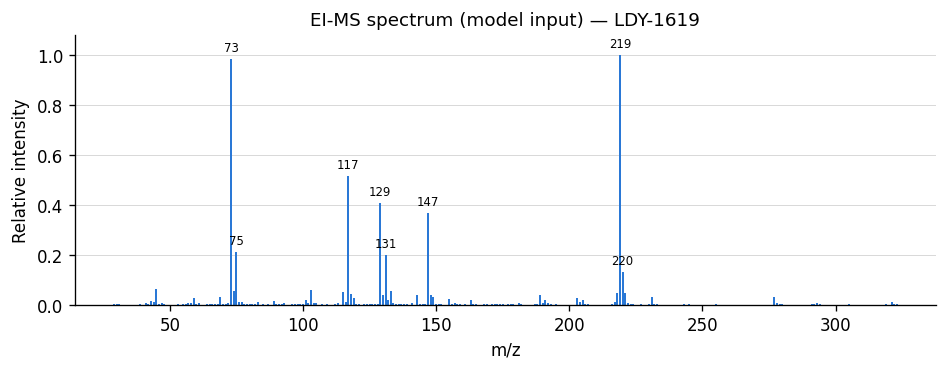

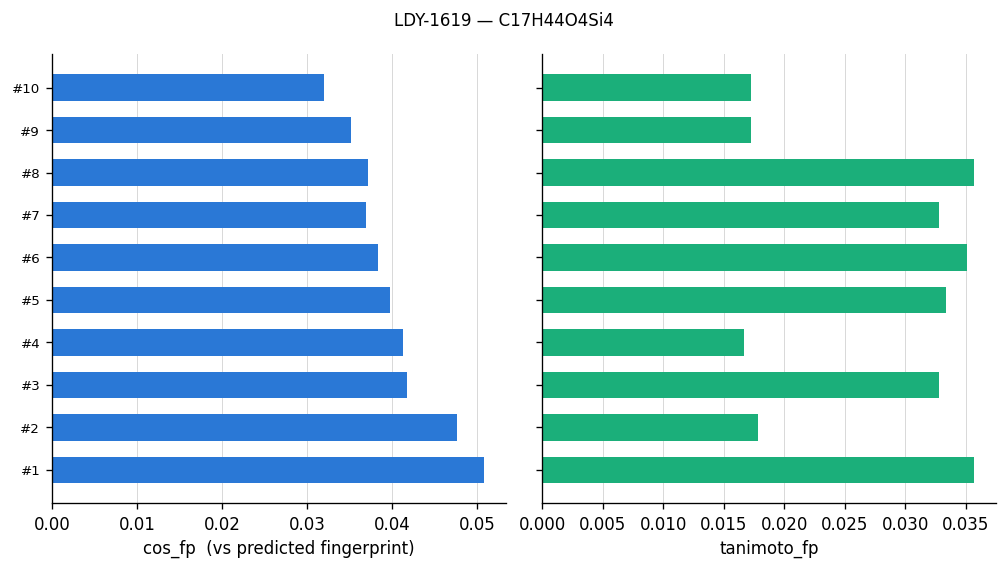

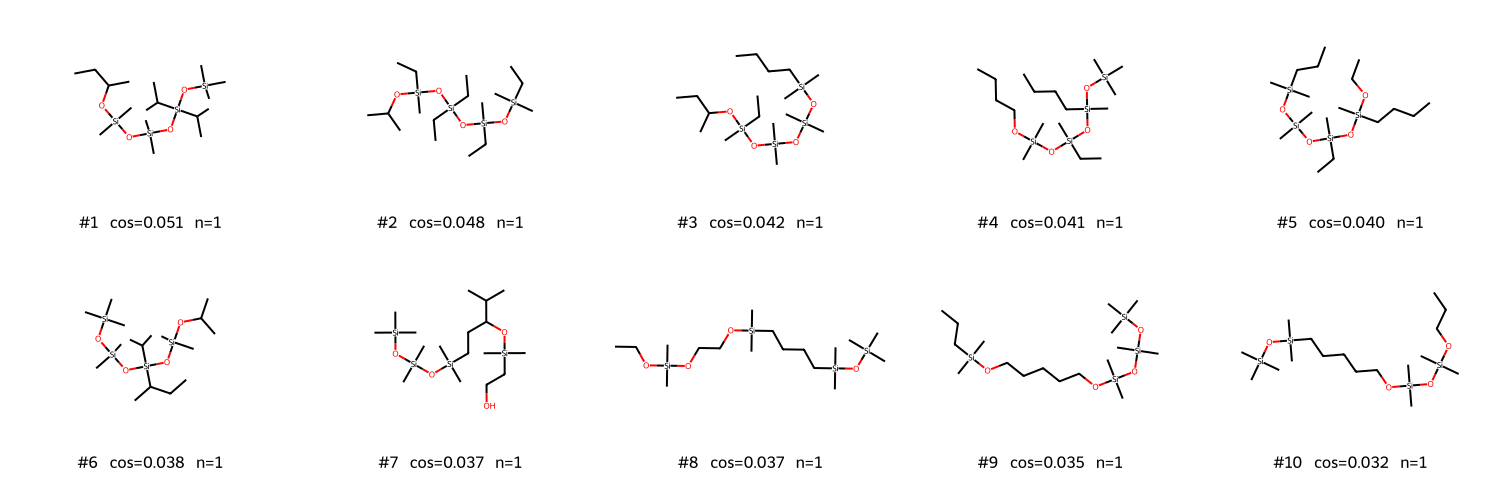

 rank                                                      smiles  count  cos_fp  tanimoto_fp  formula_match      MW  nSi  AllRings  O_C_ratio
    1 CCC(C)O[Si](C)(C)O[Si](C)(C)O[Si](O[Si](C)(C)C)(C(C)C)C(C)C      1   0.051        0.036           True 424.232    4         0      0.235
    2     CC[Si](C)(C)O[Si](C)(CC)O[Si](CC)(CC)O[Si](C)(CC)OC(C)C      1   0.048        0.018           True 424.232    4         0      0.235
    3     CCCC[Si](C)(C)O[Si](C)(C)O[Si](C)(C)O[Si](C)(CC)OC(C)CC      1   0.042        0.033           True 424.232    4         0      0.235
    4       CCCCO[Si](C)(C)O[Si](C)(CC)O[Si](C)(CCCC)O[Si](C)(C)C      1   0.041        0.017           True 424.232    4         0      0.235
    5       CCCC[Si](C)(OCC)O[Si](C)(CC)O[Si](C)(C)O[Si](C)(C)CCC      1   0.040        0.033           True 424.232    4         0      0.235
    6 CCC(C)[Si](O[Si](C)(C)OC(C)C)(O[Si](C)(C)O[Si](C)(C)C)C(C)C      1   0.038        0.035           True 424.232    4         0      0.235

In [14]:
show(names[0])

### Browse interactively

If `ipywidgets` is installed you get a dropdown and a rank-by selector; otherwise
`next_spectrum()` steps through them one at a time. Either way, `show('LDY-####')`
always works.

In [15]:
try:
    import ipywidgets as widgets

    _uid_w  = widgets.Dropdown(options=names, description='spectrum',
                               layout=widgets.Layout(width='320px'))
    _rank_w = widgets.Dropdown(options=list(SORT_KEYS), value=RANK_BY,
                               description='rank by',
                               layout=widgets.Layout(width='260px'))
    _k_w    = widgets.IntSlider(value=TOP_K, min=1, max=20, description='top-k')
    _fm_w   = widgets.Checkbox(value=PREFER_FORMULA_MATCH,
                               description='formula matches first')

    def _render(uid, rank_by, k, prefer_formula):
        show(uid, k=k, table=top_candidates(cand, k=k, rank_by=rank_by,
                                            prefer_formula=prefer_formula))

    display(widgets.interactive(_render, uid=_uid_w, rank_by=_rank_w, k=_k_w,
                                prefer_formula=_fm_w))
except ImportError:
    print('ipywidgets not installed (pip install ipywidgets) — using the stepper.')

    _cursor = {'i': -1}

    def next_spectrum(step=1):
        """Show the next spectrum; call repeatedly to walk the dataset."""
        _cursor['i'] = (_cursor['i'] + step) % N_SPECTRA
        print(f'[{_cursor["i"] + 1}/{N_SPECTRA}]')
        show(names[_cursor['i']])

    next_spectrum()

interactive(children=(Dropdown(description='spectrum', layout=Layout(width='320px'), options=('LDY-1619', 'LDY…

### Step through candidates one at a time

`show()` above prints a whole shortlist at once. This is the other mode: **run the
`browser.next()` cell again and you get the next candidate.** It walks rank 1 → 10
of a spectrum, then rolls into the next spectrum's rank 1, so a single repeated
keypress covers all 4,764 shortlisted structures.

The position lives on `browser`, which is created in the cell below — so re-running
*that* cell resets you to the start, while re-running the `browser.next()` cell
advances. Keep them separate.

| call | effect |
|---|---|
| `browser.next()` / `browser.prev()` | one candidate forward / back |
| `browser.next_spectrum()` / `browser.prev_spectrum()` | jump to rank 1 of the next / previous spectrum |
| `browser.goto('LDY-1619', rank=3)` | jump anywhere |
| `browser.keep('looks right')` | record the current candidate |
| `browser.kept_df()` | everything kept so far, as a DataFrame |

The input spectrum is drawn only when the spectrum changes, so stepping within one
shortlist stays compact.

In [16]:
import bisect


class CandidateBrowser:
    """Steps through every shortlisted candidate, one per call.

    Position is a single index into a flat (spectrum, rank) ordering, so next()
    walks rank 1..k of one spectrum and then rolls into the next spectrum's rank 1.
    Wraps around at both ends.
    """

    def __init__(self, table=None, uids=None, k=TOP_K):
        t = (table if table is not None else top)
        t = t[t['rank'] <= k].copy()
        spec_order = {u: i for i, u in enumerate(uids if uids is not None else names)}
        t['_spec'] = t['uid'].map(spec_order)
        self.rows = (t.sort_values(['_spec', 'rank'])
                      .drop(columns='_spec')
                      .reset_index(drop=True))
        self.k = k
        self.n_per_uid = self.rows.groupby('uid')['rank'].max().to_dict()
        self.starts = self.rows.index[self.rows['rank'] == 1].tolist()
        self.pos = -1               # first next() lands on 0
        self.kept = []
        self._spectrum_shown = None

    # -- navigation ----------------------------------------------------------
    def next(self, step=1):
        """Advance `step` candidates and draw. Re-run this to walk the shortlists."""
        self.pos = (self.pos + step) % len(self.rows)
        self._render()

    def prev(self, step=1):
        self.next(-step)

    def next_spectrum(self):
        i = bisect.bisect_right(self.starts, self.pos)
        self.pos = self.starts[i % len(self.starts)]
        self._render()

    def prev_spectrum(self):
        i = bisect.bisect_left(self.starts, self.pos) - 1
        self.pos = self.starts[i % len(self.starts)]
        self._render()

    def goto(self, uid, rank=1):
        uid = _resolve(uid)
        hit = self.rows.index[(self.rows['uid'] == uid) & (self.rows['rank'] == rank)]
        if not len(hit):
            raise KeyError(f'{uid} has no rank-{rank} candidate '
                           f'(it has {self.n_per_uid.get(uid, 0)})')
        self.pos = hit[0]
        self._render()

    # -- shortlisting --------------------------------------------------------
    def keep(self, note=''):
        """Record the candidate on screen; collect them with kept_df()."""
        r = self.rows.loc[self.pos]
        self.kept.append({'uid': r['uid'], 'formula': r['formula'], 'rank': r['rank'],
                          'smiles': r['smiles'], 'cos_fp': r['cos_fp'],
                          'count': r['count'], 'formula_match': r['formula_match'],
                          'note': note})
        print(f"kept {r['uid']} #{r['rank']}  —  {len(self.kept)} candidate(s) so far")

    def kept_df(self):
        return pd.DataFrame(self.kept)

    # -- rendering -----------------------------------------------------------
    def _render(self):
        r = self.rows.loc[self.pos]
        uid, n_here = r['uid'], self.n_per_uid[r['uid']]

        print(f"[{self.pos + 1}/{len(self.rows)}]  {uid}   {r['formula']}   "
              f"candidate {r['rank']} of {n_here}")

        if uid != self._spectrum_shown:      # only when the spectrum changes
            plot_spectrum(uid)
            self._spectrum_shown = uid

        print(f"  cos_fp {r['cos_fp']:.3f}   tanimoto_fp {r['tanimoto_fp']:.3f}   "
              f"sampled {r['count']}/{N_SAMPLES}   "
              f"formula {'match' if r['formula_match'] else 'MISMATCH'}")
        print(f"  MW {r['MW']:.2f}   nSi {r['nSi']}   rings {r['AllRings']}   "
              f"O/C {r['O_C_ratio']:.2f}   logP {r['LogP']:.2f}")
        print(f"  {r['smiles']}")
        display(Draw.MolToImage(Chem.MolFromSmiles(r['smiles']), size=(480, 380)))


browser = CandidateBrowser()
print(f'{len(browser.rows):,} candidates across {browser.rows["uid"].nunique()} '
      f'spectra — run the next cell repeatedly to walk them.')

4,761 candidates across 477 spectra — run the next cell repeatedly to walk them.


[265/4761]  LDY-7079   C16H36O5Si3   candidate 5 of 10
  cos_fp 0.060   tanimoto_fp 0.000   sampled 1/100   formula match
  MW 392.19   nSi 3   rings 0   O/C 0.31   logP 4.45
  CCCCC(OC(C)=O)C(=O)O[Si](C)(C[Si](C)(C)C)O[Si](C)(C)C


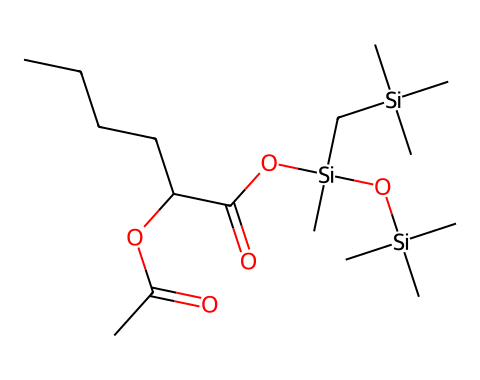

In [154]:
browser.next()

In [45]:
Chem.MolToInchiKey(Chem.MolFromSmiles("C[Si](C)(C)OC(=O)CCCC(=O)O[Si](C)(C)C"))

'UWZGPXOJVOOLSG-UHFFFAOYSA-N'

## 7. Where to look first

477 shortlists is more than anyone reads end to end. These two orderings pick the
starting points: the spectra whose rank-1 candidate scores highest, and the ones
where the shortlist is least ordered and so most needs a human.

Treating a high `cos_fp` as "the model is confident" is a heuristic, not a
calibrated statement — the score is a raw dot product and is only loosely
comparable between spectra of different size. Read this table as *a reasonable
place to start*, not as a ranking of reliability.

In [19]:
confident = (top[top['rank'] == 1]
             .merge(spread[['spread']], left_on='uid', right_index=True)
             .sort_values('cos_fp', ascending=False))

print('Highest-confidence rank-1 candidates:')
display(confident.head(15)[['uid', 'formula', 'smiles', 'count', 'cos_fp',
                            'tanimoto_fp', 'spread', 'formula_match']].round(3))

Highest-confidence rank-1 candidates:


,uid,formula,smiles,count,cos_fp,tanimoto_fp,spread,formula_match
4721,LDY-9777,C17H30O4Si,CCCCCCC1CC(CCC)O[Si](C)(OC(C)C(C)=O)O1,1,0.158,0.072,0.045,False
2097,LDY-20666,C33H58OSi,CCCCC1=CCC2C(O[Si](C)(C)C)C=CC(C)C3CC(C)C(CC1)...,1,0.156,0.062,0.055,True
1867,LDY-20616,C33H58OSi,C=C1CCC(C(C)(C)C(CCC2C(CC(C)(C)O[SiH](C)C)CCC3...,1,0.154,0.036,0.034,True
4331,LDY-5380,C17H30O4Si,CCCC(CC)O[Si](C)(C)OC(C)C(=O)CCCCCCO,1,0.152,0.072,0.034,False
4321,LDY-3831,C17H30O4Si,CCCCCCCCCC(=O)C(C)O[Si](C)(C)OCCCO,1,0.150,0.077,0.023,False
1937,LDY-20632,C28H60O3Si2,CCCCCCCCCCCCC(O[Si](C)(C)OC1CCCCC(O[Si](C)(C)C...,1,0.146,0.077,0.032,True
2627,LDY-20842,C16H30O2,CCCC(C)CCCCCCCC1CCC(=O)O1,1,0.141,0.098,0.020,True
2607,LDY-20839,C23H38O2Si,CC(C)CCC1(C(C)(C)C)CCC(C)(C)C2CC(O[Si](C)(C)O1...,1,0.140,0.014,0.027,False
2617,LDY-20841,C22H46O4Si2,CCCCCCCCCC(=O)OC1CCC(O[Si](C)(C)C)CC1O[Si](C)(C)C,1,0.139,0.079,0.048,True
3137,LDY-21115,C15H22O2,CCC(OC(=O)C(C)(C)C)c1ccccc1C,1,0.139,0.069,0.067,True


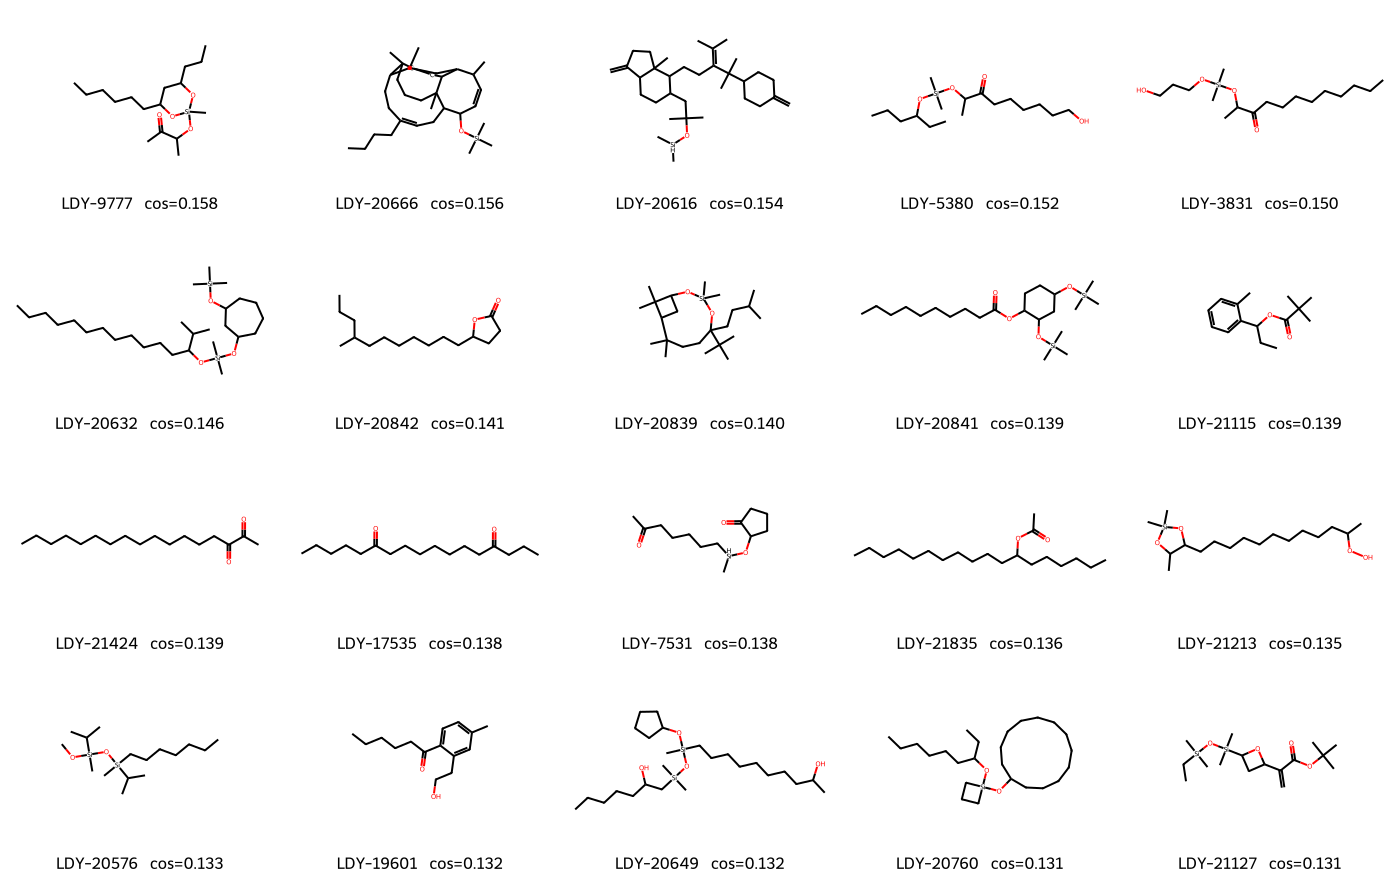

In [20]:
# Contact sheet: the rank-1 structure for the N most confident spectra.
N_SHEET = 20
sheet = confident.head(N_SHEET)
display(Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in sheet['smiles']],
    molsPerRow=5, subImgSize=(280, 220),
    legends=[f"{r.uid}  cos={r.cos_fp:.3f}" for r in sheet.itertuples()]))

Least decisive shortlists: LDY-21424, LDY-19026, LDY-21780, LDY-20682, LDY-20654, LDY-20673, LDY-20669, LDY-21139, LDY-20551, LDY-19007
=== LDY-21424 ===  formula C17H34O2  |  100/100 valid  |  38 unique structures  |  ranked by cos_fp


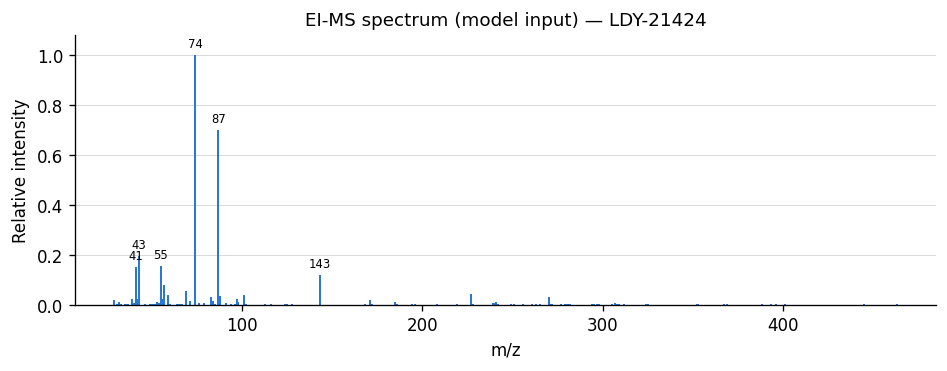

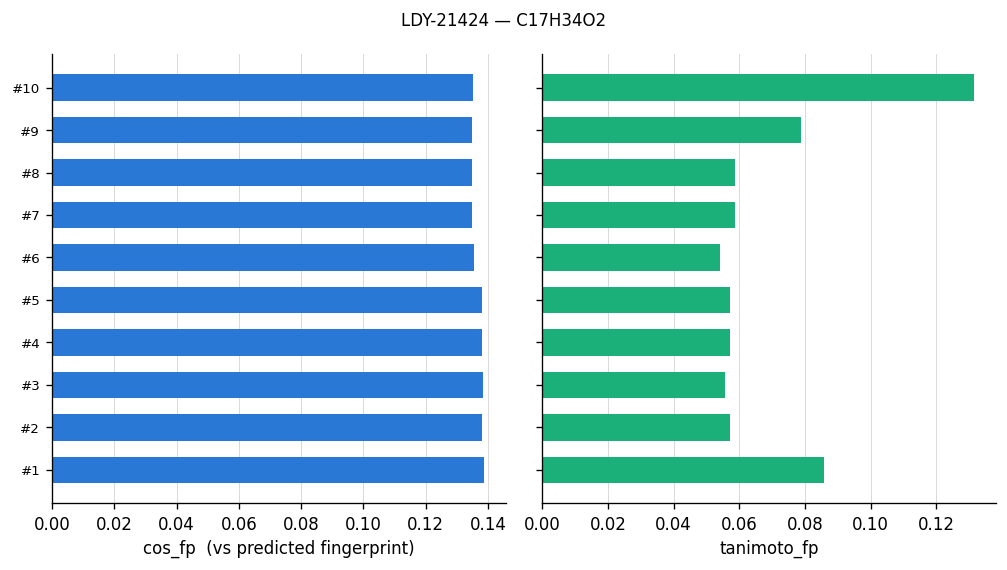

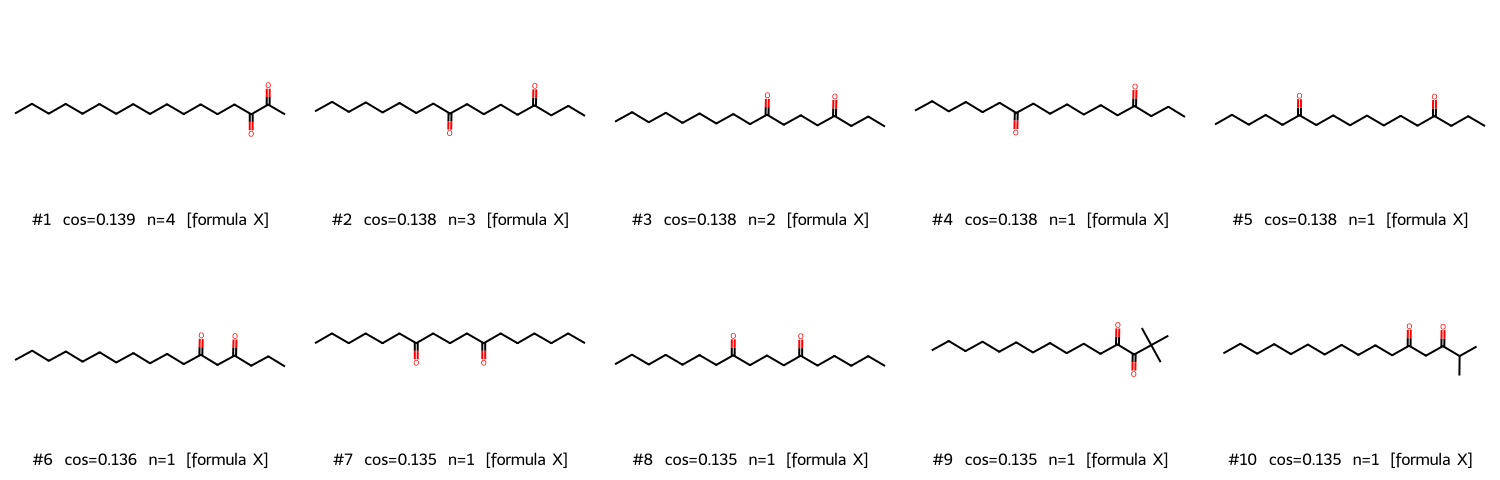

 rank                        smiles  count  cos_fp  tanimoto_fp  formula_match     MW  nSi  AllRings  O_C_ratio
    1     CCCCCCCCCCCCCCC(=O)C(C)=O      4   0.139        0.086          False 268.24    0         0      0.118
    2     CCCCCCCCC(=O)CCCCC(=O)CCC      3   0.138        0.057          False 268.24    0         0      0.118
    3     CCCCCCCCCC(=O)CCCC(=O)CCC      2   0.138        0.056          False 268.24    0         0      0.118
    4     CCCCCCC(=O)CCCCCCC(=O)CCC      1   0.138        0.057          False 268.24    0         0      0.118
    5     CCCCCC(=O)CCCCCCCC(=O)CCC      1   0.138        0.057          False 268.24    0         0      0.118
    6     CCCCCCCCCCCC(=O)CC(=O)CCC      1   0.136        0.054          False 268.24    0         0      0.118
    7     CCCCCCC(=O)CCCC(=O)CCCCCC      1   0.135        0.059          False 268.24    0         0      0.118
    8     CCCCCCCC(=O)CCCC(=O)CCCCC      1   0.135        0.059          False 268.24    0         0    

In [21]:
# The shortlists that most need a human: rank 1 barely separated from rank 10.
ambiguous = spread.sort_values('spread').head(10).index.tolist()
print('Least decisive shortlists:', ', '.join(ambiguous))
show(ambiguous[0])

## 8. Export

One row per (spectrum, candidate), ten rows per spectrum, ordered by rank — the
form to hand to someone who is not opening this notebook.

In [22]:
OUT_CSV = f'data/init_yee_inf/yee_top{TOP_K}_candidates.csv'
export_cols = ['uid', 'formula', 'rank', 'smiles', 'inchi', 'count', 'freq',
               'cos_fp', 'tanimoto_fp', 'formula_match',
               'MW', 'LogP', 'TPSA', 'RotBonds', 'AllRings', 'ArRings',
               'HeavyAtoms', 'nSi', 'O_C_ratio']
(top.sort_values(['uid', 'rank'])[export_cols]
    .to_csv(OUT_CSV, index=False))
print(f'wrote {OUT_CSV}  ({len(top):,} rows)')

# Wide form: one row per spectrum, the ten SMILES as columns.
wide = (top.pivot(index='uid', columns='rank', values='smiles')
           .rename(columns=lambda r: f'cand_{r}')
           .reset_index())
wide.insert(1, 'formula', wide['uid'].map(formula_of))
OUT_WIDE = f'data/init_yee_inf/yee_top{TOP_K}_candidates_wide.csv'
wide.to_csv(OUT_WIDE, index=False)
print(f'wrote {OUT_WIDE}  ({len(wide):,} rows)')
wide.head()

OSError: Cannot save file into a non-existent directory: 'data/init_yee_inf'